# EDS 232 Machine Learning Competition (2026)
## Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

### Background

This notebook predicts **dissolved inorganic carbon (DIC, µmol/kg)** in seawater samples collected off the California coast by the **California Cooperative Oceanic Fisheries Investigations (CalCOFI)** program.

| Feature | Description | Units |
|---|---|---|
| CTDTEMP_ITS90 | Sea water temperature | °C |
| TA | Total alkalinity | µmol/kg |
| Salinity_PSS78 | Sea water practical salinity | ppt (PSS78) |
| Depth | Sample depth below the surface | meters |

**Target:** DIC (µmol/kg) &nbsp;|&nbsp; **Metric:** Mean Squared Error (MSE)

We fit seven models: Gradient Boosting, Random Forest, XGBoost (v1 & v2), LightGBM, CatBoost, Ridge Regression, and Lasso Regression. Ridge and Lasso are tuned via cross-validated lambda search following the same procedure used in EDS 232 HW3.

## 1. Setup

In [1]:
# Install gradient boosting libraries to the active kernel's Python environment
import sys
!{sys.executable} -m pip install xgboost lightgbm catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Load labeled training data and unlabeled test set
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

# Four oceanographic features and DIC target as specified by the competition
predictors = ['CTDTEMP_ITS90', 'TA', 'Salinity_PSS78', 'Depth']
response   = 'DIC'

# Feature matrix and target vector
X = train[predictors]
y = train[response]

print(f'Training samples : {train.shape[0]}')
print(f'Test samples     : {test.shape[0]}')
print(f'Features         : {len(predictors)}')
train.head()

Training samples : 3389
Test samples     : 848
Features         : 4


,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


## 2. Exploratory Data Analysis

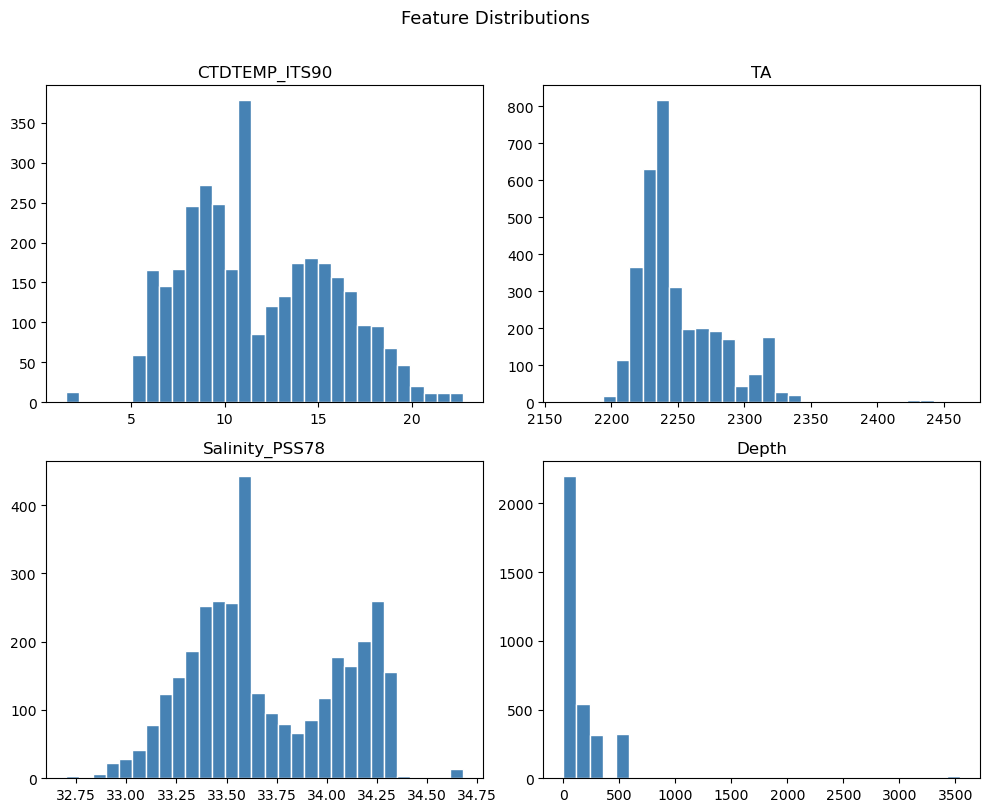

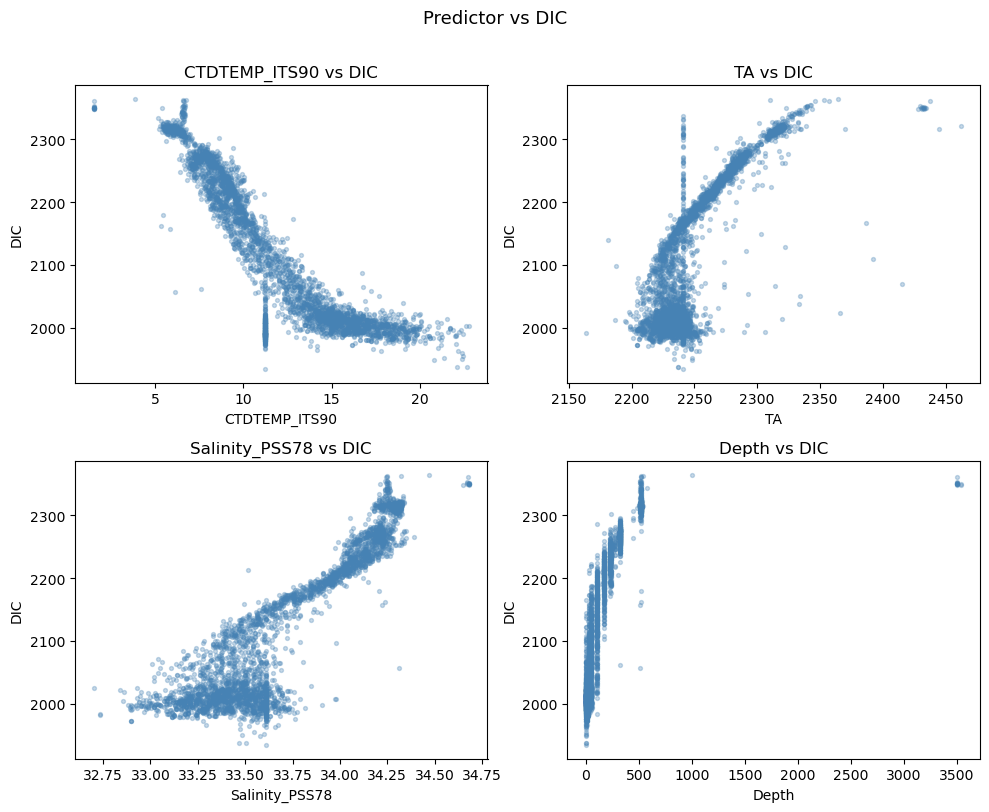

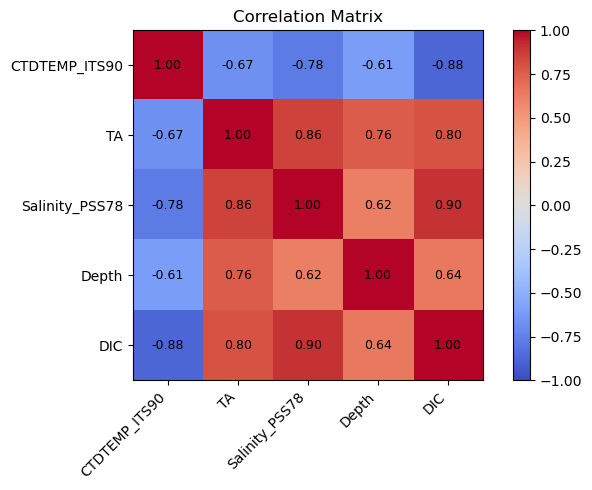

Outliers (IQR method):
  CTDTEMP_ITS90: 0 outliers
  TA: 70 outliers
  Salinity_PSS78: 0 outliers
  Depth: 15 outliers


In [2]:
# Distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), predictors):
    ax.hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Scatter vs DIC
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), predictors):
    ax.scatter(train[col], train[response], alpha=0.3, s=8, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(response)
    ax.set_title(f'{col} vs DIC')
plt.suptitle('Predictor vs DIC', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Correlation matrix
corr = train[predictors + [response]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Outliers
print('Outliers (IQR method):')
for col in predictors:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col}: {n} outliers')

## 3. Train / Validation Split & Scaling

80/20 split with `random_state=42` to match the existing models. The `StandardScaler` is fit on training data only and applied to both sets — required for Ridge and Lasso; tree-based models use the unscaled data.

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit on train only — prevents test leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')

Train : 2711 samples
Val   : 678 samples


## 4. Models

### 4a. Gradient Boosting

Best hyperparameters from prior `RandomizedSearchCV` (50 iterations, 5-fold CV, scoring=R²): `subsample=0.7, n_estimators=200, min_samples_leaf=1, max_depth=3`.

In [4]:
gb = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, min_samples_leaf=1,
    subsample=0.7, random_state=42
)
gb.fit(X_train, y_train)

mse_gb = mean_squared_error(y_val, gb.predict(X_val))
r2_gb  = r2_score(y_val, gb.predict(X_val))
print(f'Gradient Boosting — Val MSE: {mse_gb:.4f}  |  R2: {r2_gb:.4f}')

Gradient Boosting — Val MSE: 162.3172  |  R2: 0.9882


### 4b. Random Forest

Best hyperparameters from prior `GridSearchCV` (5-fold CV, scoring=R²): `max_depth=10, min_samples_leaf=1, n_estimators=500`. Refit with `n_estimators=1000` and OOB scoring enabled.

In [5]:
rf = RandomForestRegressor(
    n_estimators=1000, max_depth=10, min_samples_leaf=1,
    oob_score=True, bootstrap=True, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

mse_rf = mean_squared_error(y_val, rf.predict(X_val))
r2_rf  = r2_score(y_val, rf.predict(X_val))
print(f'Random Forest — Val MSE: {mse_rf:.4f}  |  R2: {r2_rf:.4f}')
print(f'OOB R2        : {rf.oob_score_:.4f}')

Random Forest — Val MSE: 158.6345  |  R2: 0.9885
OOB R2        : 0.9831


### 4c. XGBoost v1

Manually tuned configuration from prior exploration. Currently the best-scoring submission on Kaggle (public MSE ≈ 222).

In [6]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2222, learning_rate=0.005,
    max_depth=6, min_child_weight=0.67,
    subsample=0.8, colsample_bytree=1,
    random_state=20, verbosity=0
)
xgb.fit(X_train, y_train)

mse_xgb = mean_squared_error(y_val, xgb.predict(X_val))
r2_xgb  = r2_score(y_val, xgb.predict(X_val))
print(f'XGBoost — Val MSE: {mse_xgb:.4f}  |  R2: {r2_xgb:.4f}')

XGBoost — Val MSE: 150.8881  |  R2: 0.9891


### 4d. XGBoost v2

`RandomizedSearchCV` over a different region of the hyperparameter space: higher learning rates, shallower trees, and stronger regularization (`gamma`, `reg_alpha`, `reg_lambda`). 20 iterations, 5-fold CV, scoring=MSE.

In [7]:
# XGBoost v2 — Revised
# v1 best params: n_estimators=2222, lr=0.005, max_depth=6 (val MSE 150.89, Kaggle 222.37)
# v2 prior search found: max_depth=4, gamma=1.0 helped regularization but n_estimators=300 undertrained
# Strategy: keep depth=4 + strong gamma/reg from v2, but increase n_estimators + drop lr
# This targets better generalization (lower Kaggle MSE) at the cost of some val MSE

param_dist_xgb2 = {
    'n_estimators':     [800, 1200, 1500, 2000],   # more trees to compensate low lr
    'learning_rate':    [0.005, 0.01, 0.02, 0.05], # low lr = slower, less overfit
    'max_depth':        [3, 4, 5],                  # shallower = less overfit (v2 found 4 good)
    'subsample':        [0.7, 0.8, 0.9],            # row subsampling
    'colsample_bytree': [0.7, 0.8, 1.0],            # feature subsampling
    'gamma':            [0.5, 1.0, 2.0, 5.0],       # min loss split — key regularizer
    'reg_alpha':        [0, 0.1, 0.5],              # L1 on weights
    'reg_lambda':       [0.5, 1.0, 3.0, 5.0],      # L2 on weights
    'min_child_weight': [1, 3, 5, 10]               # min samples per leaf
}

random_search_xgb2 = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_distributions=param_dist_xgb2,
    n_iter=30,          # more iterations for larger grid
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_xgb2.fit(X_train, y_train)

print('Best Parameters:')
print(random_search_xgb2.best_params_)
print(f'\nBest CV MSE : {-random_search_xgb2.best_score_:.4f}')

xgb2 = random_search_xgb2.best_estimator_

mse_xgb2 = mean_squared_error(y_val, xgb2.predict(X_val))
r2_xgb2  = r2_score(y_val, xgb2.predict(X_val))
print(f'XGBoost v2 — Val MSE: {mse_xgb2:.4f}  |  R2: {r2_xgb2:.4f}')
print('Note: lower val MSE does not always = lower Kaggle MSE; regularization helps generalization')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 1.0, 'colsample_bytree': 0.8}

Best CV MSE : 212.0357
XGBoost v2 — Val MSE: 160.7862  |  R2: 0.9883
Note: lower val MSE does not always = lower Kaggle MSE; regularization helps generalization


### 4e. LightGBM

Histogram-based gradient boosting from Microsoft. Faster than sklearn's `GradientBoostingRegressor` and handles skewed features like `Depth` well via leaf-wise tree growth. `n_estimators` is fixed at 500; learning rate and tree structure are tuned via `RandomizedSearchCV` (20 iterations, 5-fold CV).

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 15, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Best CV MSE: 218.3045
LightGBM — Val MSE: 163.3053  |  R2: 0.9882


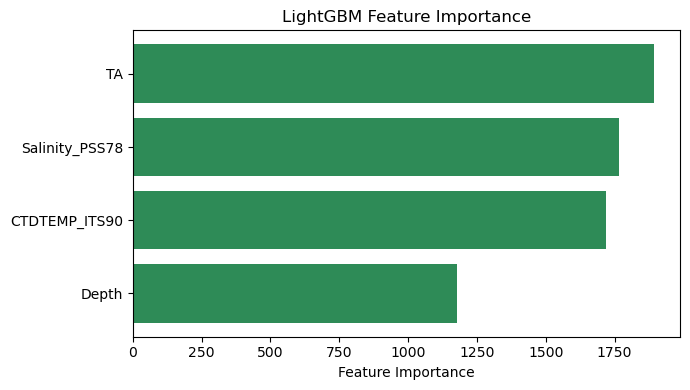

In [8]:
# Reduced search space to keep runtime reasonable
# n_estimators is fixed at a moderate value; learning_rate and tree structure are tuned
# Early stopping halts training when val loss stops improving — avoids over-iterating

from sklearn.model_selection import cross_val_score

param_dist_lgb = {
    'learning_rate':    [0.01, 0.05, 0.1],
    'num_leaves':       [15, 31, 63],
    'max_depth':        [4, 6, 10],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [0, 0.1, 1.0]
}

# n_estimators fixed at 500 with early stopping — faster than searching over [500,1000,2000]
lgb_base = LGBMRegressor(
    n_estimators=500,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

random_search_lgb = RandomizedSearchCV(
    lgb_base,
    param_distributions=param_dist_lgb,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_lgb.fit(X_train, y_train)

print('Best Parameters:')
print(random_search_lgb.best_params_)
print(f'\nBest CV MSE: {-random_search_lgb.best_score_:.4f}')

lgb = random_search_lgb.best_estimator_

mse_lgb = mean_squared_error(y_val, lgb.predict(X_val))
r2_lgb  = r2_score(y_val, lgb.predict(X_val))
print(f'LightGBM — Val MSE: {mse_lgb:.4f}  |  R2: {r2_lgb:.4f}')

# Feature importance
fi_lgb = pd.DataFrame({
    'Feature':    predictors,
    'Importance': lgb.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi_lgb['Feature'], fi_lgb['Importance'], color='seagreen')
ax.set_xlabel('Feature Importance')
ax.set_title('LightGBM Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4f. Ridge Regression

Same procedure as EDS 232 HW3: `StandardScaler` → `RidgeCV` with 100 alphas on a log scale from 1e-4 to 1e4, 10-fold CV, scored on negative MSE. Ridge shrinks all coefficients toward zero but retains all features.

In [9]:
# 100 lambda values on a log scale — same grid as HW3
lambdas = np.logspace(-4, 4, 100)

ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

print(f'Best lambda chosen by CV: {ridge_cv.alpha_:.4f}')

mse_ridge = mean_squared_error(y_val, ridge_cv.predict(X_val_scaled))
r2_ridge  = r2_score(y_val, ridge_cv.predict(X_val_scaled))
print(f'Ridge — Val MSE: {mse_ridge:.4f}  |  R2: {r2_ridge:.4f}')

pd.DataFrame({'Feature': predictors, 'Ridge Coefficient': ridge_cv.coef_})

Best lambda chosen by CV: 0.0001
Ridge — Val MSE: 1444.1040  |  R2: 0.8953


,Feature,Ridge Coefficient
0,CTDTEMP_ITS90,-54.628748
1,TA,15.014877
2,Salinity_PSS78,50.290323
3,Depth,-1.579802


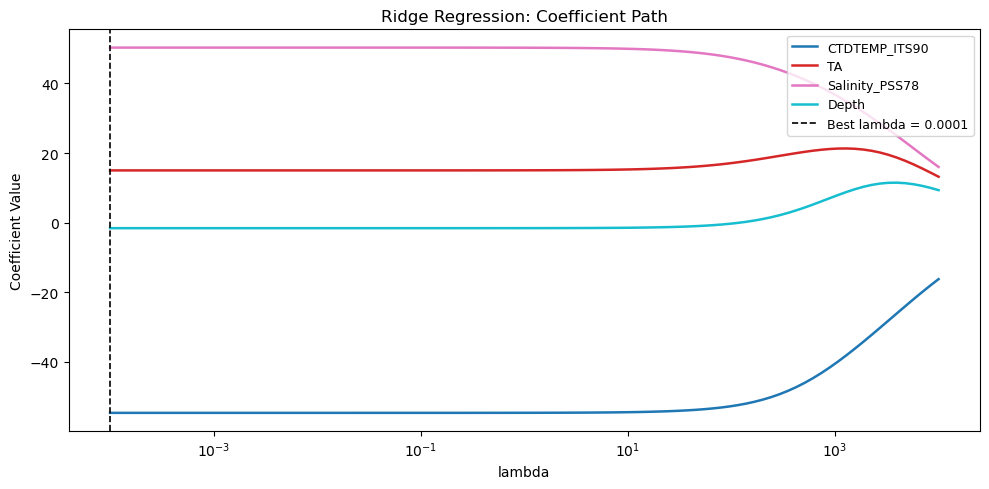

In [10]:
# Coefficient path — shows how shrinkage increases with lambda
coef_paths = np.array([
    Ridge(alpha=lam).fit(X_train_scaled, y_train).coef_
    for lam in lambdas
])

colors = plt.cm.tab10(np.linspace(0, 1, len(predictors)))
plt.figure(figsize=(10, 5))
for j, (name, color) in enumerate(zip(predictors, colors)):
    plt.plot(lambdas, coef_paths[:, j], label=name, color=color, linewidth=1.8)
plt.axvline(ridge_cv.alpha_, color='black', linestyle='--', linewidth=1.2,
            label=f'Best lambda = {ridge_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Path')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### 4g. Lasso Regression

Same lambda grid and 10-fold CV as Ridge. Lasso uses L1 regularization, which can shrink coefficients to exactly zero (implicit feature selection). `max_iter=10000` ensures convergence.

In [11]:
lasso_cv = LassoCV(alphas=lambdas, cv=10, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f'Best lambda chosen by CV: {lasso_cv.alpha_:.6f}')

mse_lasso = mean_squared_error(y_val, lasso_cv.predict(X_val_scaled))
r2_lasso  = r2_score(y_val, lasso_cv.predict(X_val_scaled))
print(f'Lasso — Val MSE: {mse_lasso:.4f}  |  R2: {r2_lasso:.4f}')

# Zeros = features dropped by L1 penalty
pd.DataFrame({'Feature': predictors, 'Lasso Coefficient': lasso_cv.coef_})

Best lambda chosen by CV: 0.628029
Lasso — Val MSE: 1438.1055  |  R2: 0.8957


,Feature,Lasso Coefficient
0,CTDTEMP_ITS90,-53.829178
1,TA,13.337086
2,Salinity_PSS78,50.747941
3,Depth,-0.000000


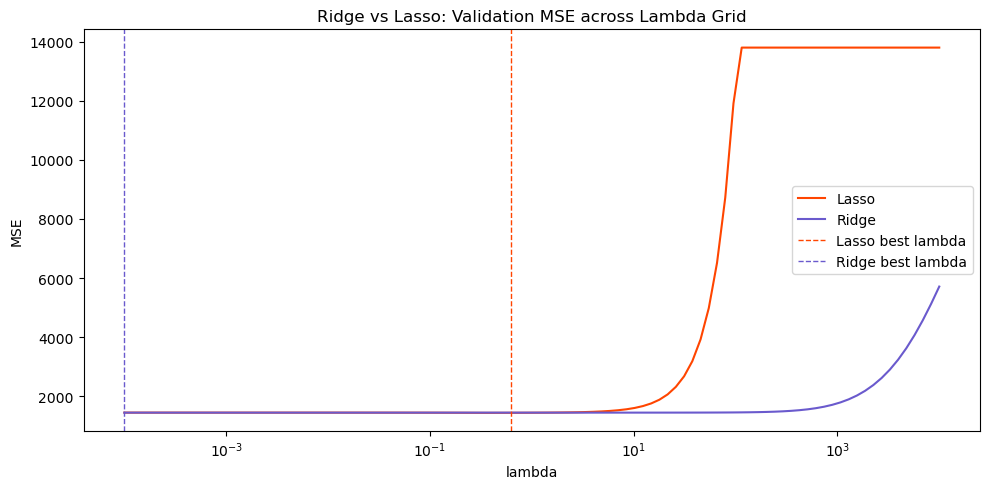

In [12]:
# MSE vs lambda across the full grid for both linear models
mse_lasso_path, mse_ridge_path = [], []
for lam in lambdas:
    mse_lasso_path.append(mean_squared_error(
        y_val, Lasso(alpha=lam, max_iter=10000).fit(X_train_scaled, y_train).predict(X_val_scaled)))
    mse_ridge_path.append(mean_squared_error(
        y_val, Ridge(alpha=lam).fit(X_train_scaled, y_train).predict(X_val_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso_path, label='Lasso', color='orangered')
plt.plot(lambdas, mse_ridge_path, label='Ridge', color='slateblue')
plt.axvline(lasso_cv.alpha_, color='orangered', linestyle='--', linewidth=1, label='Lasso best lambda')
plt.axvline(ridge_cv.alpha_, color='slateblue', linestyle='--', linewidth=1, label='Ridge best lambda')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.title('Ridge vs Lasso: Validation MSE across Lambda Grid')
plt.legend()
plt.tight_layout()
plt.show()

### 4h. CatBoost

CatBoost is a gradient boosting library developed by Yandex. It uses ordered boosting and symmetric trees, which reduces overfitting and often requires less tuning than XGBoost. `RandomizedSearchCV` over key hyperparameters (50 iterations, 5-fold CV, scoring=MSE).

In [13]:
from catboost import CatBoostRegressor

param_dist_cb = {
    'iterations':        [500, 1000, 2000],
    'learning_rate':     [0.01, 0.05, 0.1],
    'depth':             [4, 6, 8, 10],
    'l2_leaf_reg':       [1, 3, 5, 10],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bylevel': [0.7, 0.8, 1.0]
}

cb_base = CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)

random_search_cb = RandomizedSearchCV(
    cb_base,
    param_distributions=param_dist_cb,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search_cb.fit(X_train, y_train)

print('Best Parameters:')
print(random_search_cb.best_params_)
print(f'\nBest CV MSE: {-random_search_cb.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bylevel=0.8, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   0.7s
[CV] END colsample_bylevel=0.8, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   0.7s
[CV] END colsample_bylevel=0.8, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   0.7s
[CV] END colsample_bylevel=0.8, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   0.7s
[CV] END colsample_bylevel=0.8, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   0.7s
[CV] END colsample_bylevel=1.0, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.7; total time=   0.9s
[CV] END colsample_bylevel=1.0, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.7; total time=   0.9s
[CV] END colsample_bylevel=0.7, depth=10, iterati

/opt/anaconda3/envs/eds220-env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bylevel=0.7, depth=10, iterations=500, l2_leaf_reg=5, learning_rate=0.05, subsample=0.8; total time=   2.8s
[CV] END colsample_bylevel=1.0, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.7; total time=   1.4s
[CV] END colsample_bylevel=1.0, depth=6, iterations=1000, l2_leaf_reg=5, learning_rate=0.05, subsample=0.7; total time=   0.9s
[CV] END colsample_bylevel=0.8, depth=8, iterations=2000, l2_leaf_reg=5, learning_rate=0.1, subsample=0.8; total time=   4.1s
[CV] END colsample_bylevel=1.0, depth=6, iterations=500, l2_leaf_reg=3, learning_rate=0.05, subsample=1.0; total time=   0.7s
[CV] END colsample_bylevel=0.8, depth=8, iterations=2000, l2_leaf_reg=5, learning_rate=0.1, subsample=0.8; total time=   3.8s
[CV] END colsample_bylevel=0.8, depth=8, iterations=2000, l2_leaf_reg=5, learning_rate=0.1, subsample=0.8; total time=   4.4s
[CV] END colsample_bylevel=1.0, depth=6, iterations=500, l2_leaf_reg=3, learning_rate=0.05, subsample=1.0; total ti

CatBoost — Val MSE: 158.4086  |  R2: 0.9885


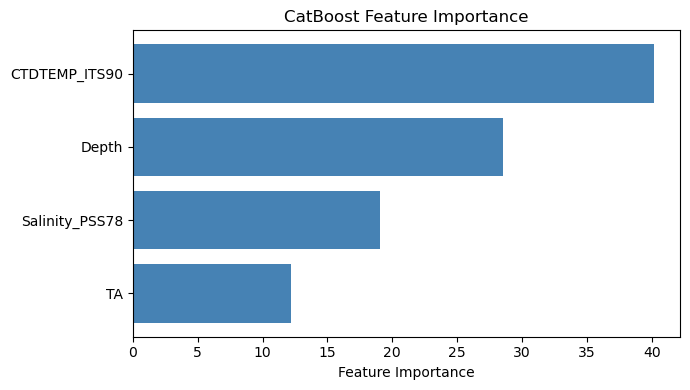

In [14]:
cb = random_search_cb.best_estimator_

mse_cb = mean_squared_error(y_val, cb.predict(X_val))
r2_cb  = r2_score(y_val, cb.predict(X_val))
print(f'CatBoost — Val MSE: {mse_cb:.4f}  |  R2: {r2_cb:.4f}')

# Feature importance
fi = pd.DataFrame({
    'Feature':    predictors,
    'Importance': cb.get_feature_importance()
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi['Feature'], fi['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('CatBoost Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Model Comparison

In [15]:
summary = pd.DataFrame({
    'Model': [
        'Gradient Boosting', 'Random Forest',
        'XGBoost v1', 'XGBoost v2',
        'LightGBM', 'CatBoost',
        'Ridge CV', 'Lasso CV'
    ],
    'Tuning': [
        'n_estimators=200, max_depth=3, subsample=0.7',
        'n_estimators=1000, max_depth=10',
        'n_estimators=2222, lr=0.005, max_depth=6',
        str(random_search_xgb2.best_params_),
        str(random_search_lgb.best_params_),
        str(random_search_cb.best_params_),
        f'lambda={ridge_cv.alpha_:.4f} (RidgeCV, 10-fold CV)',
        f'lambda={lasso_cv.alpha_:.6f} (LassoCV, 10-fold CV)'
    ],
    'Val MSE': [mse_gb, mse_rf, mse_xgb, mse_xgb2, mse_lgb, mse_cb, mse_ridge, mse_lasso],
    'Val R2':  [r2_gb,  r2_rf,  r2_xgb,  r2_xgb2,  r2_lgb,  r2_cb,  r2_ridge,  r2_lasso]
})
summary['Val MSE'] = summary['Val MSE'].round(4)
summary['Val R2']  = summary['Val R2'].round(4)
summary.sort_values('Val MSE')

,Model,Tuning,Val MSE,Val R2
2,XGBoost v1,"n_estimators=2222, lr=0.005, max_depth=6",150.8881,0.9891
5,CatBoost,"{'subsample': 0.8, 'learning_rate': 0.05, 'l2_...",158.4086,0.9885
1,Random Forest,"n_estimators=1000, max_depth=10",158.6345,0.9885
3,XGBoost v2,"{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alp...",160.7862,0.9883
0,Gradient Boosting,"n_estimators=200, max_depth=3, subsample=0.7",162.3172,0.9882
4,LightGBM,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alp...",163.3053,0.9882
7,Lasso CV,"lambda=0.628029 (LassoCV, 10-fold CV)",1438.1055,0.8957
6,Ridge CV,"lambda=0.0001 (RidgeCV, 10-fold CV)",1444.1040,0.8953


**Interpretation:**  
Ridge and Lasso serve as interpretable linear baselines. Because DIC has strong nonlinear relationships with depth and temperature, the tree-based models are expected to outperform them on MSE. XGBoost v1 vs v2 shows the effect of tuning different hyperparameter regions. The linear models satisfy the two-model requirement and quantify how much the nonlinear learners gain over a regularized linear fit.

## 6. Generate Submissions

All named submission files are generated below — one per model.

### Random Forest Submission

In [16]:
rf_preds = rf.predict(test[predictors])
sub_rf = pd.DataFrame({'id': test['id'], 'DIC': rf_preds})
sub_rf.to_csv('submission_rf_v1.csv', index=False)
print('Random Forest submission saved.')
sub_rf.head()

Random Forest submission saved.


,id,DIC
0,6,2001.197382
1,8,1985.992757
2,12,1984.341163
3,14,1983.462907
4,17,1986.351871


### XGBoost v1 Submission

In [17]:
xgb_preds = xgb.predict(test[predictors])
sub_xgb = pd.DataFrame({'id': test['id'], 'DIC': xgb_preds})
sub_xgb.to_csv('submission_xgb_v1.csv', index=False)
print('XGBoost v1 submission saved.')
sub_xgb.head()

XGBoost v1 submission saved.


,id,DIC
0,6,1998.816528
1,8,1984.991333
2,12,1984.756104
3,14,1981.229614
4,17,1986.351196


### XGBoost v2 Submission

In [18]:
xgb2_preds = xgb2.predict(test[predictors])
sub_xgb2 = pd.DataFrame({'id': test['id'], 'DIC': xgb2_preds})
sub_xgb2.to_csv('submission_xgb_v2.csv', index=False)
print('XGBoost v2 submission saved.')
sub_xgb2.head()

XGBoost v2 submission saved.


,id,DIC
0,6,2000.254883
1,8,1987.109009
2,12,1987.948486
3,14,1984.422363
4,17,1989.244751


### LightGBM Submission

In [19]:
lgb_preds = lgb.predict(test[predictors])
sub_lgb = pd.DataFrame({'id': test['id'], 'DIC': lgb_preds})
sub_lgb.to_csv('submission_lgb_v1.csv', index=False)
print('LightGBM submission saved.')
sub_lgb.head()

LightGBM submission saved.


,id,DIC
0,6,1997.090006
1,8,1983.454449
2,12,1982.644914
3,14,1973.308894
4,17,1986.773554


### CatBoost Submission

In [20]:
cb_preds = cb.predict(test[predictors])
sub_cb = pd.DataFrame({'id': test['id'], 'DIC': cb_preds})
sub_cb.to_csv('submission_catboost_v1.csv', index=False)
print('CatBoost submission saved.')
sub_cb.head()

CatBoost submission saved.


,id,DIC
0,6,1998.127956
1,8,1983.036200
2,12,1985.374868
3,14,1978.340089
4,17,1987.050526


### Ridge Submission

In [21]:
ridge_preds = ridge_cv.predict(scaler.transform(test[predictors]))
sub_ridge = pd.DataFrame({'id': test['id'], 'DIC': ridge_preds})
sub_ridge.to_csv('submission_ridge_v1.csv', index=False)
print('Ridge submission saved.')
sub_ridge.head()

Ridge submission saved.


,id,DIC
0,6,2025.513679
1,8,2059.720928
2,12,1976.155418
3,14,1954.949891
4,17,2110.121825


### Lasso Submission

In [22]:
lasso_preds = lasso_cv.predict(scaler.transform(test[predictors]))
sub_lasso = pd.DataFrame({'id': test['id'], 'DIC': lasso_preds})
sub_lasso.to_csv('submission_lasso_v1.csv', index=False)
print('Lasso submission saved.')
sub_lasso.head()

Lasso submission saved.


,id,DIC
0,6,2025.568445
1,8,2058.758467
2,12,1977.122756
3,14,1956.265630
4,17,2109.617988
